In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, lognorm
from scipy.integrate import cumulative_trapezoid
import time

from efficient_fpt.models import aDDModel
from efficient_fpt.io import save_addm_experiment
from efficient_fpt.utils import generate_addm_experiment, get_alternating_mu_array

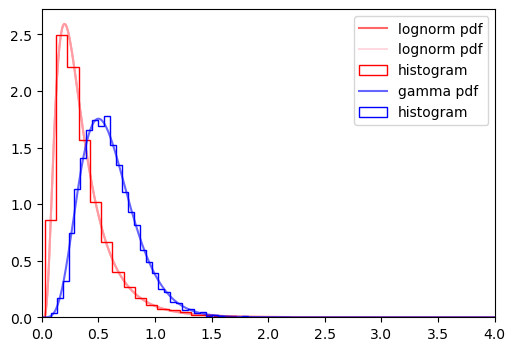

In [2]:
# aDDModel is now imported from efficient_fpt.models as a standalone class.
# Use model.to_multistage_model(mu1, mu2, sacc_array) for single-trial
# DDModel interface (simulate_trajs, drift_coeff, boundaries, etc.)

num_samples = 10000
rng = np.random.default_rng()
# sample lognormal waiting times and visualize
mu = 6.39
sigma = 0.63
waitTs1 = rng.lognormal(mean=mu, sigma=sigma, size=num_samples) / 2000

# sample gamma waiting times and visualize
shape_param = 6
scale_param = 0.1
waitTs2 = rng.gamma(shape_param, scale_param, num_samples)


fig, ax = plt.subplots(figsize=(10, 4))
x = np.linspace(0, max(np.max(waitTs1), np.max(waitTs2)), 2000)
ax.plot(x, lognorm.pdf(x, s=sigma, scale=np.exp(mu + np.log(1 / 2000))), "r", alpha=0.6, label="lognorm pdf")
ax.plot(x, lognorm.pdf(x / np.exp(mu + np.log(1 / 2000)), s=sigma) / np.exp(mu + np.log(1 / 2000)), "pink", alpha=0.6, label="lognorm pdf")
ax.hist(waitTs1, histtype="step", bins=40, color="red", density=True, label="histogram")
ax.plot(x, gamma.pdf(x, a=shape_param, scale=scale_param), "b", alpha=0.6, label="gamma pdf")
ax.hist(waitTs2, histtype="step", bins=40, color="blue", density=True, label="histogram")
ax.autoscale(tight=True, axis="x")
ax.set_aspect("equal")
ax.legend()
plt.show()

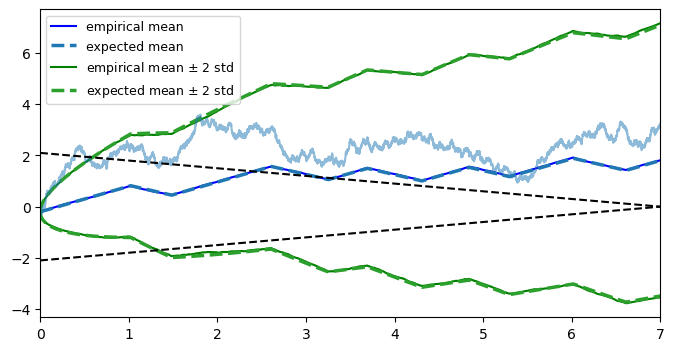

In [3]:
mu1, mu2 = 1.0, -0.8
a, b = 2.1, 0.3
T = a / b
x0 = -0.2

shape_param, scale_param = 6, 0.1
rng = np.random.default_rng()
fixations = rng.gamma(shape_param, scale_param, 1000)
sacc_array = np.insert(np.cumsum(fixations), 0, 0)
sacc_array = sacc_array[sacc_array < T]
flag = np.random.binomial(1, 0.5)
# Pre-swap mu1/mu2 based on flag
m1, m2 = (mu2, mu1) if flag else (mu1, mu2)
sigma = 1
num = 2000

# Use a dummy eta/kappa — we already have mu1/mu2 directly
model = aDDModel(eta=0.0, kappa=1.0, sigma=sigma, a=a, b=b, x0=x0)
ddm = model.to_multistage_model(m1, m2, sacc_array)
t_grid, X_grids = ddm.simulate_trajs(T=T, Nt=1000 * T, num=num)

expected_mean = cumulative_trapezoid(ddm.drift_coeff(_, t_grid), t_grid, initial=0) + x0
empirical_mean = np.mean(X_grids, axis=0)
expected_std = sigma * np.sqrt(t_grid)
empirical_std = np.std(X_grids, axis=0)


fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(t_grid, empirical_mean, label="empirical mean", c="b")
ax.plot(t_grid, expected_mean, label="expected mean", linewidth=2.5, linestyle="--", c="tab:blue")
ax.plot(t_grid, empirical_mean + 2 * empirical_std, label=r"empirical mean $\pm$ 2 std", c="g")
ax.plot(t_grid, empirical_mean - 2 * empirical_std, c="g")
ax.plot(t_grid, expected_mean + 2 * expected_std, label=r"expected mean $\pm$ 2 std", linewidth=2.5, linestyle="--", c="tab:green")
ax.plot(t_grid, expected_mean - 2 * expected_std, linewidth=2.5, linestyle="--", c="tab:green")
ax.plot(t_grid, X_grids[:1, :].T, alpha=0.5)
ax.plot(t_grid, ddm.upper_bdy(t_grid), c='k', linestyle="--")
ax.plot(t_grid, ddm.lower_bdy(t_grid), c='k', linestyle="--")
ax.autoscale(axis="x", tight=True)
ax.legend(fontsize=9)
plt.show()

In [4]:
num_data = 50000

eta = 0.7
kappa = 0.5

start_time = time.time()
result = generate_addm_experiment(
    n_trials=num_data, eta=eta, kappa=kappa, sigma=sigma, a=a, b=b, x0=x0,
    gamma_shape=shape_param, gamma_scale=scale_param,
    dt=1e-5, T=T, random_state=None,
)
print(f"Elapsed time: {time.time() - start_time:.3f} seconds")

decision_data = np.column_stack([result["rt"], result["choice"]])
mu_data = [result["mu_array_data"][i, :result["d_data"][i]] for i in range(num_data)]
sacc_data = [result["sacc_array_data"][i, :result["d_data"][i]] for i in range(num_data)]
r1_data = result["r1_data"]
r2_data = result["r2_data"]
flag_data = result["flag_data"]
d_data = result["d_data"]

Elapsed time: 1510.187 seconds


In [ ]:
max_d = int(d_data.max())
min_d, avg_d = int(d_data.min()), d_data.mean()
min_d, max_d, avg_d

(1, 13, 3.302)

In [6]:
# the minimum fixation time
min_fixations = [np.min(np.diff(sacc_array)) for sacc_array in sacc_data if len(sacc_array) > 1]
print(min(min_fixations))

0.03712219304673692


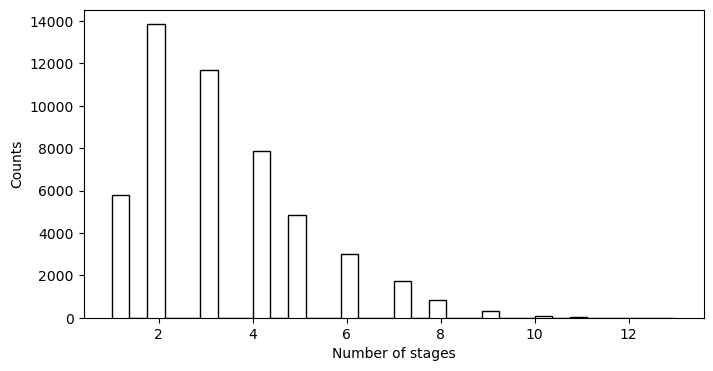

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(d_data, histtype="step", color="k", bins=32)
ax.set_xlabel("Number of stages")
ax.set_ylabel("Counts")
plt.show()

padded each data to maximum length for uniform storage

the effective length (i.e. before padding) satisfies `length(mu_array[i]) = length(sacc_array[i]) = d`, so after padding `length(mu_array_data[i]) = length(sacc_array_data[i]) = max_d`

In [8]:
fname = "addm_data_" + time.strftime("%Y%m%d-%H%M%S") + ".pkl"
save_addm_experiment(fname, result)